In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('data/raw/shopping.csv')

In [2]:
df.head()

,Customer ID,Age,Gender,Item Purchased,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Shipping Type,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,3475,NaN,Male,Jacket,30.904467,Maine,M,Burnt orange,Fall,4.0,Standard,No,0,Credit Card,NaN
1,3698,21.0,Female,Backpack,31.588259,NaN,L,Turquoise,Winter,2.0,Express,No,1,Credit Card,Monthly
2,2756,31.0,Male,Leggings,24.231704,Nevada,M,Terra cotta,Winter,4.0,Standard,No,0,Credit Card,NaN
3,3340,NaN,Male,Pajamas,33.918834,Nebraska,M,Black,Winter,NaN,Standard,No,2,Credit Card,Bi-Weekly
4,3391,38.0,Male,Sunglasses,36.545487,Oregon,S,Aubergine,Summer,NaN,Standard,No,0,Credit Card,NaN


In [3]:
df.describe()

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3510.000000,3900.000000,1431.000000,3900.000000
mean,1950.500000,34.256695,38.708329,3.904962,5.841538
std,1125.977353,10.616340,11.504923,1.105952,5.843695
min,1.000000,18.000000,11.392520,1.000000,0.000000
25%,975.750000,26.000000,29.332617,4.000000,1.000000
50%,1950.500000,33.000000,36.953004,4.000000,4.000000
75%,2925.250000,41.000000,48.739596,5.000000,9.000000
max,3900.000000,75.000000,69.567481,5.000000,20.000000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3510 non-null   float64
 2   Gender                  3900 non-null   object 
 3   Item Purchased          3900 non-null   object 
 4   Purchase Amount (USD)   3900 non-null   float64
 5   Location                3510 non-null   object 
 6   Size                    3900 non-null   object 
 7   Color                   3900 non-null   object 
 8   Season                  3900 non-null   object 
 9   Review Rating           1431 non-null   float64
 10  Shipping Type           3900 non-null   object 
 11  Promo Code Used         3900 non-null   object 
 12  Previous Purchases      3900 non-null   int64  
 13  Payment Method          3900 non-null   object 
 14  Frequency of Purchases  1560 non-null   

In [5]:
#got curious with claude who suggested I look for missing values using the below
df.isnull().sum()

Customer ID                  0
Age                        390
Gender                       0
Item Purchased               0
Purchase Amount (USD)        0
Location                   390
Size                         0
Color                        0
Season                       0
Review Rating             2469
Shipping Type                0
Promo Code Used              0
Previous Purchases           0
Payment Method               0
Frequency of Purchases    2340
dtype: int64

1. What are the most popular colors by season?

In [6]:
color_season = pd.pivot_table(df, index='Color', columns='Season', aggfunc='size', fill_value=0)
color_season

Season,Fall,Spring,Summer,Winter
Color,,,,
Aubergine,101,4,14,144
Baby blue,17,83,99,24
Black,103,5,12,155
Brick red,103,7,14,140
Brown,117,5,5,120
Burnt orange,110,4,10,138
Fuchsia,5,59,103,21
Lavender,19,63,120,13
Lemon yellow,11,62,112,18


In [7]:
for season in color_season.columns:
    print(f"\nTop 5 colors in {season}:")
    print(color_season[season].sort_values(ascending=False).head(5))


Top 5 colors in Fall:
Color
Brown           117
Ruby Red        112
Burnt orange    110
Terra cotta     108
Black           103
Name: Fall, dtype: int64

Top 5 colors in Spring:
Color
Baby blue     83
White         73
Pale peach    68
Lavender      63
Periwinkle    63
Name: Spring, dtype: int64

Top 5 colors in Summer:
Color
Lavender        120
Lemon yellow    112
Periwinkle      105
Pale peach      104
Fuchsia         103
Name: Summer, dtype: int64

Top 5 colors in Winter:
Color
Black           155
Aubergine       144
Brick red       140
Burnt orange    138
Ruby Red        132
Name: Winter, dtype: int64


The most popular color by season are as follows: 

Fall: Brown, 117 purchased
Spring: Baby blue, 83 purchased
Summer: Lavender, 120 purchased
Winter: Black, 155 purchased

2. What is the most popular clothing item by season?

In [11]:
#had trouble with this part: aggfunc='size', fill_value=0)
popular_season = pd.pivot_table(df, index='Season', columns='Item Purchased', aggfunc='size', fill_value=0)
popular_season

Item Purchased,Backpack,Belt,Boots,Dress,Gloves,Handbag,Hoodie,Jacket,Jeans,Leggings,Pajamas,Running Shoes,Scarf,Shorts,Socks,Sunglasses,Sweater,T-shirt
Season,,,,,,,,,,,,,,,,,,
Fall,81,34,59,46,81,41,67,58,54,71,77,35,66,40,87,49,86,24
Spring,0,0,0,92,0,90,0,0,0,0,0,106,0,97,0,100,0,96
Summer,0,0,0,156,0,136,0,0,0,0,0,168,0,177,0,163,0,142
Winter,144,0,107,0,136,0,135,108,0,157,135,0,130,0,124,0,145,0


In [9]:
for season in popular_season.index:
    print(f"\nTop 5 clothing in {season}:")
    #claude helped me with this next one
    print(popular_season.loc[season].sort_values(ascending=False).head(5))


Top 5 clothing in Fall:
Item Purchased
Socks       87
Sweater     86
Backpack    81
Gloves      81
Pajamas     77
Name: Fall, dtype: int64

Top 5 clothing in Spring:
Item Purchased
Running Shoes    106
Sunglasses       100
Shorts            97
T-shirt           96
Dress             92
Name: Spring, dtype: int64

Top 5 clothing in Summer:
Item Purchased
Shorts           177
Running Shoes    168
Sunglasses       163
Dress            156
T-shirt          142
Name: Summer, dtype: int64

Top 5 clothing in Winter:
Item Purchased
Leggings    157
Sweater     145
Backpack    144
Gloves      136
Hoodie      135
Name: Winter, dtype: int64


The most popular clothing item by season are as follows: 

Fall: Socks, 87 purchased
Spring: Running Shoes, 106 purchased
Summer: Shorts, 177 purchased
Winter: Leggings, 157 purchased

3. What is the effect of promo codes on the dollar amount of purchases?

In [10]:
#groupby() tells pandas which column to split the data by
#square brackets tells pandas which column to do the math on
df.groupby('Promo Code Used')['Purchase Amount (USD)'].mean()

Promo Code Used
No     30.172085
Yes    50.023814
Name: Purchase Amount (USD), dtype: float64

People who did not use a promo code spent $30.17 on average while people who did use a promo code spent $50.02 on average. Promo code users spent about $20 more per purchase. This could mean that customers are more willing to buy higher-priced items when they have a promo code or that promo codes target larger purchases.

4. When do users leave a review?

In [12]:
df.groupby('Season')['Review Rating'].count()

Season
Fall      387
Spring    205
Summer    340
Winter    499
Name: Review Rating, dtype: int64

Users leave the most reviews in the winter, this could mean that the holiday season allows more time for people to assess items and leave reviews, we could also check if people purchase the most items in the winter to see if there is a correlation between the number of items purchased per season and review ammounts per season. 

⭐ MY QUESTIONS ⭐

1. ⭐ Which season experiences the most revenue?

In [14]:
# .sum provides the total in the Purchase Ammount (USD) column, instead of .count which would give me the number of purchases per season
# added .sort_values(ascending=False) with claude's help
df.groupby('Season')['Purchase Amount (USD)'].sum().sort_values(ascending=False)

Season
Winter    50681.682052
Fall      41004.570210
Summer    36446.813666
Spring    22829.415359
Name: Purchase Amount (USD), dtype: float64

Winter experiences the most revenue with a total of $50,681.68 generated for the season. Based on this information it would be wise to dig deeper into the specific items purchased, colors and sizes. With this information, the company can coordinate with teams like manufacturing, distribution and marketing to focus efforts on driving more revenue for this season.

2. ⭐ Do the locations that leave the most reviews also spend the most?

In [36]:
# claude definitely helped me out with this one

# df.groupby('Location') — Split the entire dataset into groups, one for each state. So all the Maine rows go in one group, all the Nevada rows in another, etc.

# .agg({ — "Aggregate" means calculate a summary for each group. The dictionary inside tells pandas what to calculate and on which column.

# 'Review Rating': 'count' — For each location group, count the non-null values in the Review Rating column. This tells you how many reviews that location left.
    #'Review Rating' is on the left side of the : — that's the dictionary key. It tells pandas which column to look at.
    #'count' is on the right side of the : — that's the dictionary value. It tells pandas what to do with that column.
            # {'key': 'value'}
            # {'which column': 'what function to apply'}
            # {'Review Rating': 'count'}

# 'Purchase Amount (USD)': 'sum' — For each location group, add up all the values in Purchase Amount (USD). This tells you total spending for that location.

# }) — Closes the dictionary and the .agg() call.

# "Group the data by location, then for each location, count the reviews and sum up the spending."

# The result is a table with one row per location and two columns

location_data = df[df['Location'].notna()]

location_data.groupby('Location').agg({
    'Review Rating': 'count',
    'Purchase Amount (USD)': 'sum'
    #sorting by reviews
}).sort_values('Review Rating', ascending=False)

,Review Rating,Purchase Amount (USD)
Location,,
California,39,3474.548095
Nebraska,37,3195.731939
Louisiana,36,2981.809948
Maine,35,2732.648536
Virginia,33,2683.482885
Idaho,33,3097.347396
Tennessee,32,2535.804528
Alabama,31,2959.628238
Illinois,31,2946.890380


In [35]:
location_data = df[df['Location'].notna()]

location_data.groupby('Location').agg({
    'Review Rating': 'count',
    'Purchase Amount (USD)': 'sum'
    #sorting by purchase ammount 
}).sort_values('Purchase Amount (USD)', ascending=False)

,Review Rating,Purchase Amount (USD)
Location,,
California,39,3474.548095
Nebraska,37,3195.731939
Delaware,29,3140.865589
West Virginia,22,3127.541031
Idaho,33,3097.347396
Indiana,23,3086.464246
Montana,30,3077.969533
Maryland,31,3048.546749
New York,26,3039.720209


California and Nebraska are the top 2 locations that both leave the most reviews and have the most purchase amount. Based on this information we can A/B test offers and promo codes in these locations to determine additional behavior. We can also incentivize reviews to locations that leave the least reviews to see if their purchase ammount increases or decreases.

3. ⭐ Is there a relationship between item color and purchase amount?

In [24]:
df.groupby('Color')['Purchase Amount (USD)'].count().sort_values(ascending=False)

Color
Black                   275
Brick red               264
Aubergine               263
Burnt orange            262
Terra cotta             259
Ruby Red                258
Brown                   247
Mauve                   240
Muted mustard yellow    238
Baby blue               223
Lavender                215
Lemon yellow            203
Pale peach              200
White                   194
Fuchsia                 188
Periwinkle              186
Turquoise               185
Name: Purchase Amount (USD), dtype: int64

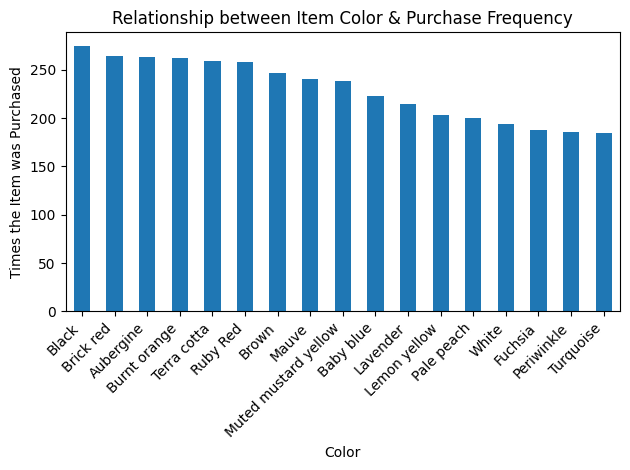

In [ ]:
color_count = df.groupby('Color')['Purchase Amount (USD)'].count().sort_values(ascending=False)
color_count.plot(kind='bar')
plt.title('Relationship between Item Color & Purchase Frequency')
plt.ylabel('Times the Item was Purchased')
plt.xlabel('Color')
# got the .xticks and .tight_layout from claude, I was curious about tilting the variables in the X axis
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

The relationship between color and purchase frequency is weak because the counts range from about 185 to 275, which is relatively even across all colors. Black is the most purchased color and Turquoise is the least, but the differences aren't dramatic. Based on this, keeping our current approach as is would be ideal since color doesn't appear to be a strong driver of purchasing behavior.

4. ⭐ What is the correlation between the Item Purchased and the Color and Size?

In [31]:
# Item vs Color

pd.pivot_table(df, index='Item Purchased', columns='Color', aggfunc='size', fill_value=0)

Color,Aubergine,Baby blue,Black,Brick red,Brown,Burnt orange,Fuchsia,Lavender,Lemon yellow,Mauve,Muted mustard yellow,Pale peach,Periwinkle,Ruby Red,Terra cotta,Turquoise,White
Item Purchased,,,,,,,,,,,,,,,,,
Backpack,22,6,16,26,29,24,2,2,2,24,11,3,2,24,26,2,4
Belt,2,0,4,4,7,4,0,1,0,4,2,0,0,4,2,0,0
Boots,22,4,16,17,7,17,6,4,0,17,14,1,0,20,19,2,0
Dress,9,29,7,11,6,9,28,26,36,3,4,34,21,5,9,31,26
Gloves,30,5,28,18,24,20,1,4,3,17,14,3,3,22,18,4,3
Handbag,10,27,8,3,9,6,23,32,25,6,10,18,26,7,4,25,28
Hoodie,21,2,18,21,21,18,3,0,7,17,19,2,1,23,24,3,2
Jacket,17,4,25,11,16,17,0,2,2,21,13,1,0,12,21,2,2
Jeans,5,1,3,7,7,4,0,0,0,8,5,1,0,5,7,0,1


In [ ]:
# claude helped me here, trying to make the table above easier to read
# idxmax(axis=1) returns the column name (color) with the highest count for each row (item).

item_color = pd.pivot_table(df, index='Item Purchased', columns='Color', aggfunc='size', fill_value=0)
item_color.idxmax(axis=1)

Item Purchased
Backpack                        Brown
Belt                            Brown
Boots                       Aubergine
Dress                    Lemon yellow
Gloves                      Aubergine
Handbag                      Lavender
Hoodie                    Terra cotta
Jacket                          Black
Jeans                           Mauve
Leggings                    Brick red
Pajamas                         Black
Running Shoes               Baby blue
Scarf                           Black
Shorts                      Baby blue
Socks                        Ruby Red
Sunglasses                 Pale peach
Sweater          Muted mustard yellow
T-shirt                    Periwinkle
dtype: object

In [34]:
# Item vs Size

pd.pivot_table(df, index='Item Purchased', columns='Size', aggfunc='size', fill_value=0)

Size,L,M,S,XL
Item Purchased,,,,
Backpack,56,105,37,27
Belt,11,12,7,4
Boots,52,68,35,11
Dress,91,131,43,29
Gloves,64,99,28,26
Handbag,60,119,52,36
Hoodie,57,83,35,27
Jacket,39,81,29,17
Jeans,15,26,7,6


There is no strong correlation between the item purchased and its color or size. Each item has a different top color with no clear pattern, and Medium is the most purchased size across all items regardless of the item type. Color and size preferences appear to be independent of what item is being bought.